# Stage 3 – EDA, Steps 12–13: Data Leakage Audit and the Observations → Decisions Summary

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `10_eda_imbalance.ipynb` (Step 11)
**This is the last EDA notebook.** After it, the project moves to preprocessing (`src/features.py`) and modelling.

---

## Part 1 – Step 12: Data leakage audit

### What leakage is

**Data leakage** happens when a model, during training or evaluation, gets information it **won't have when it's used for real**. The model then looks better in testing than it will ever be in practice.

> *Analogy:* a student who has seen the exam answers scores 95%. The score is real, but it says nothing about what they know. Leakage produces exactly this kind of score.

It's one of the most common reasons machine-learning projects fail after deployment, and a favourite viva topic, because it's easy to create by accident and hard to spot afterwards.

### The three kinds we check

| Kind | What it looks like | Example in our project |
|---|---|---|
| **Target leakage** | A feature that contains, or is computed from, the answer. | A description saying "$1,200/month" when the price is $1,200. |
| **Train–test contamination** | The same (or nearly the same) listing on both sides of the split. | A repost in the test set whose twin is in training. |
| **Pipeline leakage** | A step that learns from data (an average, a scale, an encoding) is fitted on data it will later be evaluated on. | Encoding each region by an average rent that includes the listing's own rent. |

### Two principles behind every check

1. **The platform test.** For every input, ask: *"will the user of the prediction platform have this value when they ask for a prediction?"* If not, it can't be a feature. (A user enters size, rooms, region and amenities; they don't enter the rent or a Craigslist ID.)
2. **Evidence, not assumptions.** Each risk gets a number: how often it happens and how much it would inflate a score. Two sections (12.5, 12.6) *demonstrate* the damage by running a leaky and a correct version side by side.

### About the test set in this notebook

Section 12.4 re-checks the split, and for that it has to open `test.parquet`. It does this in the most limited way possible: it turns each test listing into **fingerprints** (IDs and hash codes of its values), compares them with the training set, and then deletes the test data. **No statistic of the test rents is ever computed or shown**, so the test set remains an unseen final exam.

---

## Part 2 – Step 13: Observations → decisions

The second half collects everything the EDA decided into the documents the report and the pipeline need:

- the full **observations → decisions table** (from `observations_log.csv`), exported for the report;
- the **pipeline specification**: exactly how each column is treated for each model family, with the evidence for each choice;
- the **limitations** list;
- a **completeness check** that every planned EDA step has logged its findings.

## Sections

| Section | Content |
|---|---|
| 12.1 | Column audit: which columns may be features? |
| 12.2 | Identifiers and time drift |
| 12.3 | Does the description state the rent? |
| 12.4 | Split integrity re-check (fingerprints only) |
| 12.5 | Demonstration: target encoding with and without cross-fitting |
| 12.6 | Demonstration: random vs grouped cross-validation |
| 12.7 | Other checks: derived columns, cleaning rules, error groups |
| 12.8 | The leakage risk register |
| 12.9 | Log the Step 12 observations |
| 13.1 | Is every EDA step logged? |
| 13.2 | The observations → decisions table |
| 13.3 | The pipeline specification |
| 13.4 | Limitations |
| 13.5 | Log the summary |

## 12.0 Setup

**What this cell does:** the usual imports and helpers. It loads the **training set** and adds `log_price` and `log_sqfeet`. Blank laundry and parking values become `"missing"` (as the pipeline will treat them). It also prints every column in the training file, because the column audit (12.1) works on all of them, not just the 16 model features.

**Two settings for the demonstrations (analysis conventions, not cleaning rules, so they live here):**

- `CV_DEMO_ROWS = 40_000`: the random-vs-grouped cross-validation demo in 12.6 uses whole listing *families* until about 40,000 listings, so it runs in a reasonable time.
- `DESC_MIN_CHARS = 50`: descriptions shorter than this are too generic to count as the "same listing" in the split re-check (the same rule Step 7 used).

**How to read the output:** 150,404 training listings (as in every step since 8) and the list of columns.

In [16]:
# 12.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import re
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

train = load_train()          # the TRAINING set; the test set is only fingerprinted in 12.4
train["log_price"] = np.log1p(train["price"])
train["log_sqfeet"] = np.log1p(train["sqfeet"])
for col in ["laundry_options", "parking_options"]:
    train[col] = train[col].fillna("missing")

CV_DEMO_ROWS = 40_000   # 12.6: size of the cross-validation demonstration (whole families)
DESC_MIN_CHARS = 50     # 12.4: shorter descriptions are too generic to identify a listing (Step 7 rule)

print(f"Training listings: {len(train):,}")
print(f"Columns in the training file ({train.shape[1]}): {list(train.columns)}")

def short_region(url):
    return str(url).replace("https://", "").replace(".craigslist.org", "")

def wrap_style(df, fmt=None):
    # Show long text columns wrapped and left-aligned
    s = df.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
    return s.format(fmt) if fmt else s

show_obs(11)   # Step 11 findings, to confirm the handover

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training listings: 150,404
Columns in the training file (25): ['id', 'url', 'region', 'region_url', 'price', 'type', 'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'laundry_options', 'parking_options', 'image_url', 'description', 'lat', 'long', 'state', 'group_id', 'log_price', 'log_sqfeet']


,step,observation,evidence,decision
0,11-Imbalance,"Listings per price band: $250-$750 14.8%, $750...","11.1 band table, bar chart and log histogram",Keep the natural population (no oversampling o...
1,11-Imbalance,"Location-only baseline (region median, GroupKF...",11.2 baseline table; reports/baseline_location...,Every model must clearly beat this baseline un...
2,11-Imbalance,Baseline bias by true band: +35.7% (cheapest) ...,11.3 bias charts and tables,Strong regression to the mean in the tails: ev...
3,11-Imbalance,Every category keeps its own column in every C...,11.4 category and rare-home tables,Report these groups separately in the final ev...
4,11-Imbalance,"Listings across regions: Gini 0.53, largest 10...","11.5 Lorenz curve, error by region size, worst...",Predictions are less reliable in thinly covere...
5,11-Imbalance,"Student-layout homes: 442 listings, baseline b...",11.6 group table and band mix,Behave differently from other large homes (per...
6,11-Imbalance,23 error-analysis groups fixed before the fina...,11.7 plan table; reports/error_analysis_plan.csv,Step 14 reports the final model's error for ex...


## 12.1 Column audit: which columns may be features?

**What this cell does:** it gives **every column** in the training file a **role**, and checks that nothing forbidden is in `MODEL_FEATURES` (the list the pipeline will use):

| Role | Columns | May be a feature? |
|---|---|---|
| target | `price` | no, it's the answer |
| model feature | the 16 in `MODEL_FEATURES` | yes |
| identifier | `id`, `url`, `image_url`, `region_url`'s twin `region` | no |
| free text | `description` | no (12.3 shows why) |
| grouping key | `group_id` | no, used only to build cross-validation folds |
| helper | `log_price`, `log_sqfeet` (added in this notebook) | no; `log_sqfeet` is recreated inside the pipeline |

For each column it also shows its **unique share**: the number of different values divided by the number of rows. A column where almost every row is different (unique share close to 100%) behaves like an **ID**: a flexible model can memorise it instead of learning anything general.

**Why identifiers are dangerous even though they "mean nothing":** a Random Forest given `id` could learn *"IDs around 7,049,xxx,xxx rent for $1,400"*, because reposts and neighbouring posts from the same complex often have close IDs and similar prices. That pattern disappears for new listings, so the model would look good in testing and fail in use.

**Why `region` (the name) is excluded but `region_url` is used:** Step 1 found **11 region names shared by different places** (for example three different "Jackson"s). The name would merge them; the URL keeps them apart.

**How to read the output:** the table of roles, and one verdict line: **PASS** if `MODEL_FEATURES` contains no target, identifier, text, grouping key or price-derived column.

In [17]:
# 12.1 Column audit

ROLE = {TARGET: "target", "group_id": "grouping key (CV only)", "description": "free text",
        "id": "identifier", "url": "identifier", "image_url": "identifier",
        "region": "identifier (ambiguous region name)",
        "log_price": "helper (derived from the target)", "log_sqfeet": "helper (recreated in the pipeline)"}
rows = []
for col in train.columns:
    role = "model feature" if col in MODEL_FEATURES else ROLE.get(col, "other (not used)")
    rows.append({"column": col, "role": role, "dtype": str(train[col].dtype),
                 "unique_share_%": train[col].nunique() / len(train) * 100,
                 "in MODEL_FEATURES": "yes" if col in MODEL_FEATURES else ""})
audit = pd.DataFrame(rows).set_index("column").sort_values(["in MODEL_FEATURES", "role"], ascending=[False, True])
display(audit.style.format({"unique_share_%": "{:.1f}%"}))

forbidden = {TARGET, "group_id", "description", "id", "url", "image_url", "region", "log_price"}
price_like = {c for c in train.columns if "price" in c.lower() or "ppsf" in c.lower()}
bad_features = sorted((forbidden | price_like) & set(MODEL_FEATURES))
id_like_features = [c for c in MODEL_FEATURES if audit.loc[c, "unique_share_%"] > 50 and c not in ["lat", "long", "sqfeet"]]
column_audit_pass = not bad_features and not id_like_features
print(f"Forbidden or price-derived columns in MODEL_FEATURES: {bad_features or 'none'}")
print(f"Categorical features that behave like IDs (> 50% unique): {id_like_features or 'none'}")
print("Column audit:", "PASS" if column_audit_pass else "FAIL - fix MODEL_FEATURES in utils.py")

,role,dtype,unique_share_%,in MODEL_FEATURES
column,,,,
region_url,model feature,str,0.3%,yes
type,model feature,str,0.0%,yes
sqfeet,model feature,int64,1.9%,yes
beds,model feature,int64,0.0%,yes
baths,model feature,float64,0.0%,yes
cats_allowed,model feature,int64,0.0%,yes
dogs_allowed,model feature,int64,0.0%,yes
smoking_allowed,model feature,int64,0.0%,yes
wheelchair_access,model feature,int64,0.0%,yes


Forbidden or price-derived columns in MODEL_FEATURES: none
Categorical features that behave like IDs (> 50% unique): none
Column audit: PASS


## 12.2 Identifiers and time drift

**What this cell does:**

1. It checks that `id` and `url` are **unique** in the training set (each listing appears once after deduplication).
2. It uses `id` for one legitimate purpose: **Craigslist post IDs increase over time**, so sorting by `id` puts listings roughly in the order they were posted. The cell splits the listings into 10 equal groups (**deciles**) by ID and plots the median rent of each, and computes the Spearman correlation between ID and rent.

**Why check time?** A model assumes the future looks like the past. If rents rose steadily *during* the period the data was collected, then (a) `id` would secretly carry information about price (another reason to exclude it), and (b) a model trained on this snapshot would under-predict rents today. This is called **temporal drift** or **concept drift**.

**How to read the output:**

- **A flat line and ρ close to 0** → no meaningful price trend within the collection period. The dataset behaves as one snapshot.
- **A rising line** → rents moved during collection; this becomes a limitation, and a time-aware split would need to be considered.
- **Either way, the dataset is a snapshot of one period.** The platform predicts rents *as they were then*. For use today, the model would need retraining on fresh listings. That's a **limitation for the report**, not a leak.

id: 150,404 unique values, 0 duplicated
url: 150,404 unique values, 0 duplicated


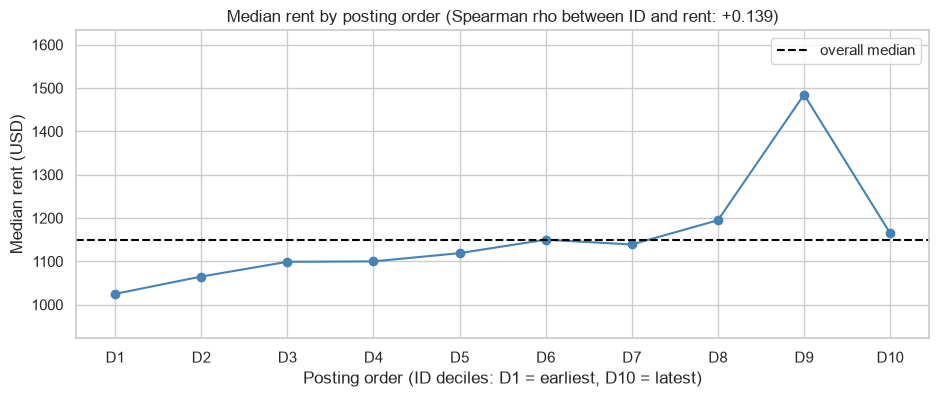

Median rent, earliest vs latest tenth of posts: $1,025 -> $1,165 (+13.7%)


In [18]:
# 12.2 Identifier uniqueness and a time-drift check

for col in ["id", "url"]:
    if col in train.columns:
        dup = train[col].duplicated().sum()
        print(f"{col}: {train[col].nunique():,} unique values, {dup:,} duplicated")

if "id" in train.columns:
    id_num = pd.to_numeric(train["id"], errors="coerce")
    rho_id = spearmanr(id_num, train["price"], nan_policy="omit")[0]
    id_decile = pd.qcut(id_num.rank(method="first"), 10, labels=[f"D{i}" for i in range(1, 11)])
    drift = train.groupby(id_decile, observed=True)["price"].median()
    drift_change = (drift.iloc[-1] / drift.iloc[0] - 1) * 100

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(drift.index.astype(str), drift.values, marker="o", color="steelblue")
    ax.axhline(train["price"].median(), color="black", linestyle="--", label="overall median")
    ax.set(xlabel="Posting order (ID deciles: D1 = earliest, D10 = latest)", ylabel="Median rent (USD)",
           title=f"Median rent by posting order (Spearman rho between ID and rent: {rho_id:+.3f})")
    ax.set_ylim(drift.min() * 0.9, drift.max() * 1.1)
    ax.legend()
    save_fig("12_time_drift_by_id")
    plt.show()
    print(f"Median rent, earliest vs latest tenth of posts: ${drift.iloc[0]:,.0f} -> ${drift.iloc[-1]:,.0f} "
          f"({drift_change:+.1f}%)")
else:
    rho_id, drift_change = np.nan, np.nan
    print("No id column in the training file: time-drift check skipped")

## 12.3 Does the description state the rent?

**What this cell does:** it searches every training description for **dollar amounts** (like `$1,200`, `$950.00` or `$ 800`) with a **regular expression** (a text pattern). For each listing it then asks:

- does the description contain **any** dollar amount?
- does one of the amounts **equal the listed price** (within $1)? That's a **direct leak**: the answer written inside an input.
- is one **within 2%** of the price (for example "$1,195" when the price is $1,200)?

It also shows a few example snippets where the description states the exact price, and the share of listings containing amounts that are *not* the rent (deposits, fees, discounts).

**Why this matters:** `description` is **not** one of our features, so it can't leak today. But the audit must show that this was a **deliberate and justified** choice, not an accident. If someone later added text features (for example word counts or a language model on the description), a model could simply **read the rent from the text**. It would score brilliantly in testing and be useless in the platform, where the user doesn't type a Craigslist description.

**How to read the output:**

- **The "equals the price" share** is the size of the leak that text features would create. If it's, say, 10%, then for one listing in ten the "prediction" would be a copy of the answer.
- **The "any amount" share** is larger, because descriptions also mention deposits, application fees and specials. Those aren't the rent, but they're **correlated** with it (a $2,000 deposit suggests an expensive home), so they are a softer form of leakage too.

**Decision rule:** description stays excluded. If text is ever used, **all dollar amounts must be removed first**, and this audit re-run.

In [19]:
# 12.3 Dollar amounts in descriptions

AMOUNT = r"\$\s?(\d{1,3}(?:,\d{3})+|\d+)(?:\.\d{1,2})?"        # $1,200 / $950.00 / $ 800
AMOUNT_NC = r"\$\s?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d{1,2})?"    # same pattern without a capture group

if "description" in train.columns:
    desc = train["description"].fillna("")
    has_amount = desc.str.contains(AMOUNT_NC, regex=True)
    amounts = desc.str.extractall(AMOUNT)[0].str.replace(",", "", regex=False).astype(float)
    amounts = amounts.reset_index(level=1, drop=True)
    listing_price = train["price"].reindex(amounts.index)
    exact = ((amounts - listing_price).abs() <= 1).groupby(level=0).any()
    near = ((amounts / listing_price - 1).abs() <= 0.02).groupby(level=0).any()
    has_exact = exact.reindex(train.index, fill_value=False)
    has_near = near.reindex(train.index, fill_value=False)

    desc_leak = pd.Series({
        "descriptions with any dollar amount": has_amount.mean() * 100,
        "... one amount equals the price (within $1)": has_exact.mean() * 100,
        "... one amount within 2% of the price": has_near.mean() * 100,
        "... amounts present, none near the price (fees, deposits...)": (has_amount & ~has_near).mean() * 100,
    }, name="% of training listings")
    display(desc_leak.to_frame().style.format("{:.1f}%"))
    share_exact = desc_leak.iloc[1]
    share_of_amount_listings = has_exact.sum() / max(has_amount.sum(), 1) * 100
    print(f"Among descriptions that mention any dollar amount, {share_of_amount_listings:.1f}% state the exact rent")

    def snippet(text, price, width=60):
        # the text around the first amount equal to the price
        for m in re.finditer(AMOUNT, text):
            if abs(float(m.group(1).replace(",", "")) - price) <= 1:
                a, b = max(m.start() - width, 0), min(m.end() + width, len(text))
                return ("..." if a else "") + " ".join(text[a:b].split()) + ("..." if b < len(text) else "")
        return ""
    ex = train[has_exact].sample(min(5, int(has_exact.sum())), random_state=RANDOM_STATE)
    examples = pd.DataFrame({"price": ex["price"].map("${:,.0f}".format),
                             "text around the amount": [snippet(t, p) for t, p in zip(ex["description"].fillna(""), ex["price"])]})
    print("Examples where the description states the exact rent:")
    display(wrap_style(examples))
else:
    share_exact = np.nan
    print("No description column in the training file: check skipped")

,% of training listings
descriptions with any dollar amount,45.2%
... one amount equals the price (within $1),25.6%
... one amount within 2% of the price,26.4%
"... amounts present, none near the price (fees, deposits...)",18.8%


Among descriptions that mention any dollar amount, 56.7% state the exact rent
Examples where the description states the exact rent:


,price,text around the amount
64541,"$1,450","...r/Alcove/1BA Apartment Downtown/Loring Park, Minneapolis, MN$1450/mo KEY FEATURESSq Footage: 550 sqft.Bedrooms: 1Bathrooms:..."
142025,"$1,070","...ge, dishwasher, microwave, washer & and dryer). The rent is $1070.00 per month with a $800.00 deposit. we do allow small pets 3..."
95620,$735,"...stions. We have a lease that is month-to-month. The rent is $735 per month, $250 deposit and $50 for the background check...."
56366,$915,"Remodeled 1st Floor One bedroom, One bath in Nice area, $915 plus utilities, WD Hookups, Large rooms, Off-street parking..."
41743,"$1,275","...c.managebuilding.com/Resident/public/custom/20 RENT: $1175-$1275 *DEPENDING ON CREDIT AND BACKGROUND AMMT, LLC show contac..."


## 12.4 Split integrity re-check (fingerprints only)

**What this cell does:** it repeats Step 7's leakage checks **on the saved files**, to prove that nothing changed since the split. It opens `test.parquet` **inside a function** that converts each test listing into a set of **fingerprints** and returns only those; the test data itself is deleted immediately.

**What a fingerprint is:** a **hash** turns a row's values into a single large number, like a barcode. Two listings with exactly the same values get the same number; different listings (almost certainly) get different ones. Comparing hashes tells us whether two listings are identical **without looking at their contents**.

**The fingerprints compared (training vs test):**

| Check | Fingerprint | Expected | Why |
|---|---|---|---|
| same listing | `id`, `url` | 0 | a listing can't be on both sides |
| identical to the model | hash of the 16 features + price | 0 | Step 4 deduplication |
| same features, other price | hash of the 16 features | 0 | Step 7 put these families in one group |
| same text in the same region | description (≥ 50 characters) + region | 0 | Step 7's text families |
| same family | `group_id` | 0 | the grouped split |
| shared photo | `image_url` | small, not necessarily 0 | evidence only (Step 4): photos are reused by agents and complexes across different homes |

**How to read the output:** a table with the number and share of test listings that match a training listing on each fingerprint. The first five must be **0 (PASS)**. The shared-photo line is reported as a **residual risk**: a test listing that shares a photo with a training listing is probably from the same building or agent. It's not the same home, so it isn't a direct leak, but its rent will be easier to predict than a truly new building's. If the share is small, the effect on the test score is small.

> **Viva point:** "We re-checked the split with hashes of the test rows, so we could confirm there was no overlap without looking at the test data's contents or its rents."

In [20]:
# 12.4 Fingerprints of training vs test listings

def fingerprints(df):
    # One row per listing: identifiers and hash codes only (no values are kept)
    fp = pd.DataFrame(index=df.index)
    for col in ["id", "url", "group_id", "image_url"]:
        if col in df.columns:
            fp[col] = df[col].astype(str).where(df[col].notna())
    fp["features+price"] = pd.util.hash_pandas_object(df[MODEL_FEATURES + [TARGET]].astype(str), index=False)
    fp["features only"] = pd.util.hash_pandas_object(df[MODEL_FEATURES].astype(str), index=False)
    if "description" in df.columns:
        d = df["description"].fillna("").str.strip()
        key = pd.util.hash_pandas_object(pd.DataFrame({"d": d, "r": df["region_url"].astype(str)}), index=False)
        fp["description+region"] = key.where(d.str.len() >= DESC_MIN_CHARS)
    return fp

def test_fingerprints():
    test_df = load_test()          # opened only to fingerprint it; no statistics are computed
    fp = fingerprints(test_df)
    n = len(test_df)
    del test_df
    return fp, n

raw_train = train.copy()
for col in ["laundry_options", "parking_options"]:
    raw_train[col] = raw_train[col].replace("missing", np.nan)   # same form as the saved files
fp_train = fingerprints(raw_train)
fp_test, n_test = test_fingerprints()
del raw_train

EXPECT_ZERO = ["id", "url", "features+price", "features only", "description+region", "group_id"]
rows = []
for key in ["id", "url", "features+price", "features only", "description+region", "group_id", "image_url"]:
    if key not in fp_test.columns or key not in fp_train.columns:
        rows.append({"check": key, "test listings matching training": np.nan, "share_%": np.nan, "verdict": "not available"})
        continue
    matched = fp_test[key].dropna().isin(set(fp_train[key].dropna()))
    count = int(matched.sum())
    verdict = ("PASS" if count == 0 else "FAIL") if key in EXPECT_ZERO else "residual risk (evidence only)"
    rows.append({"check": key, "test listings matching training": count, "share_%": count / n_test * 100, "verdict": verdict})
split_check = pd.DataFrame(rows).set_index("check")
display(split_check.style.format({"test listings matching training": "{:,.0f}", "share_%": "{:.2f}%"}, na_rep="-"))

split_pass = bool((split_check.loc[split_check.index.isin(EXPECT_ZERO), "verdict"].isin(["PASS", "not available"])).all())
photo_share = split_check.loc["image_url", "share_%"] if "image_url" in split_check.index else np.nan
print(f"Test listings: {n_test:,} (fingerprints only; test data deleted)")
print("Split integrity:", "PASS" if split_pass else "FAIL - investigate before any modelling")

,test listings matching training,share_%,verdict
check,,,
id,0,0.00%,PASS
url,0,0.00%,PASS
features+price,0,0.00%,PASS
features only,0,0.00%,PASS
description+region,0,0.00%,PASS
group_id,0,0.00%,PASS
image_url,"10,379",27.60%,residual risk (evidence only)


Test listings: 37,602 (fingerprints only; test data deleted)
Split integrity: PASS


## 12.5 Demonstration: target encoding with and without cross-fitting

**Background:** `region_url` has 413 values, so it will be **target-encoded**: each region is replaced by the average (log) rent of its listings (Step 8.5). The danger: if a listing's **own rent** is part of its region's average, the encoded value already contains a piece of the answer.

**How big is that piece?** For a region with 4 listings, each listing's rent makes up **a quarter** of the average it's encoded with. For Seattle (1,698 listings) it's under 0.1%. So the leak is **worst in small regions**, exactly the ones Step 11 found hardest to predict.

**What this cell does:** it "predicts" each listing's log rent with its region's average rent in two ways, and compares the scores (R² on log rent) overall and by region size:

1. **Leaky (in-sample):** the region average includes the listing itself, the way a naive `groupby().mean()` on the whole training set would do it.
2. **Correct (cross-fitted):** the region average comes only from **other folds** (`GroupKFold`, 5 folds, grouped by family), so a listing never contributes to its own encoding. This is what scikit-learn's `TargetEncoder` does during `fit_transform`, and what our pipeline must do.

**How to read the output:**

- **The gap** (leaky R² minus correct R²) is the **false improvement** that leakage would add.
- **Expect a small gap in big regions and a large gap in small ones.** In the smallest regions, the leaky version looks far better than it is.
- A model trained on leaky encodings learns to **trust the region value too much** (in training it looks almost perfect for small regions), and then fails on new listings.

**A detail for the pipeline:** `TargetEncoder`'s internal cross-fitting splits rows **at random**, not by family. So during training, a listing's near-twin can still be in the other internal folds and contribute to its encoded value. Our **outer** grouped cross-validation keeps the **scores** honest regardless. Our planned **state-prior encoder** (Step 10.5) should split by `group_id` internally as well, so training encodings are clean too.

> **Viva point:** "Target encoding must be cross-fitted. In our data, encoding regions with their in-sample mean inflates R² most in small regions, exactly where the model is weakest, which would hide the weakness."

In [21]:
# 12.5 In-sample vs cross-fitted region encoding

leaky = train.groupby("region_url")["log_price"].transform("mean")        # includes the listing itself

cross_fitted = np.full(len(train), np.nan)
for fit_idx, val_idx in GroupKFold(n_splits=5).split(train, groups=train["group_id"]):
    fit, val = train.iloc[fit_idx], train.iloc[val_idx]
    reg_mean = fit.groupby("region_url")["log_price"].mean()
    state_mean = fit.groupby("state")["log_price"].mean()
    enc = val["region_url"].map(reg_mean).fillna(val["state"].map(state_mean)).fillna(fit["log_price"].mean())
    cross_fitted[val_idx] = enc.to_numpy()
cross_fitted = pd.Series(cross_fitted, index=train.index)

def r2(pred, mask):
    y = train.loc[mask, "log_price"]
    return 1 - ((y - pred[mask]) ** 2).sum() / ((y - y.mean()) ** 2).sum()

region_counts = train["region_url"].value_counts()
band = region_size_band(train["region_url"], region_counts)
enc_rows = [{"regions": "all", "listings": len(train),
             "R2_leaky": r2(leaky, train.index == train.index), "R2_cross_fitted": r2(cross_fitted, train.index == train.index)}]
for b in band.cat.categories:
    m = (band == b).to_numpy()
    if m.sum() > 1:
        enc_rows.append({"regions": f"{b} listings", "listings": int(m.sum()),
                         "R2_leaky": r2(leaky, m), "R2_cross_fitted": r2(cross_fitted, m)})
enc_demo = pd.DataFrame(enc_rows).set_index("regions")
enc_demo["false_gain"] = enc_demo["R2_leaky"] - enc_demo["R2_cross_fitted"]
display(enc_demo.style.format({"listings": "{:,}", "R2_leaky": "{:.3f}", "R2_cross_fitted": "{:.3f}", "false_gain": "{:+.3f}"}))

small_gap = enc_demo["false_gain"].iloc[1]
overall_gap = enc_demo["false_gain"].iloc[0]
print(f"False gain from leaky encoding: {overall_gap:+.3f} R2 overall, {small_gap:+.3f} in the smallest regions")

,listings,R2_leaky,R2_cross_fitted,false_gain
regions,,,,
all,"150,404",0.481,0.474,+0.007
0-29 listings,556,0.129,0.025,+0.104
30-99 listings,"5,969",0.338,0.307,+0.031
100-499 listings,"40,880",0.438,0.426,+0.012
500+ listings,"102,999",0.453,0.449,+0.004


False gain from leaky encoding: +0.007 R2 overall, +0.104 in the smallest regions


## 12.6 Demonstration: random vs grouped cross-validation

**Background:** Step 7 found that **37% of listings have a close relative** (a repost at a different price, or the same text with a small edit), and linked them into **families** (`group_id`). Every model will be tuned with **cross-validation** on the training set, and the folds must keep families together (`GroupKFold`). This section shows what happens if they don't.

**What this cell does:**

1. It takes whole families at random until it has about `CV_DEMO_ROWS` = 40,000 listings (whole families, so the family structure is preserved).
2. It builds a **k-nearest-neighbours** model (one of our five models, k = 5) in a proper scikit-learn **pipeline**: fill missing coordinates, standardise, then k-NN. The inputs are log size, beds, baths, coordinates and the six flags.
3. It evaluates the **same model** twice with 5-fold cross-validation:
   - **random folds** (`KFold`): relatives can land on both sides;
   - **grouped folds** (`GroupKFold` on `group_id`): relatives always stay together.

**Why k-NN is a good test:** k-NN predicts from the most **similar** listings it has seen. If a listing's near-twin is in the learning folds, k-NN finds it and copies its rent. That's a lookup, not a prediction. Random folds reward that; grouped folds don't allow it.

**How to read the output:** the median absolute % error and R² for both. **The difference is optimism**: how much better the model *looks* with random folds than it really is on new listings. If random folds look clearly better, using them for tuning would also pick the wrong settings (for example a k that is too small, which is best at copying twins).

**Note that the pipeline itself is part of the lesson:** the imputer and the scaler are fitted **inside** each fold, so they never see the fold they are evaluated on. Fitting them once on all the data first would be (a small) pipeline leakage.

In [22]:
# 12.6 Random vs grouped cross-validation on the same k-NN pipeline

rng = np.random.default_rng(RANDOM_STATE)
family_sizes = train["group_id"].value_counts()
families = family_sizes.index.to_numpy().copy()
rng.shuffle(families)
chosen = families[np.cumsum(family_sizes.loc[families].to_numpy()) <= CV_DEMO_ROWS]
demo = train[train["group_id"].isin(chosen)]
in_family = demo["group_id"].map(family_sizes) > 1

X = demo[["log_sqfeet", "beds", "baths", "lat", "long", *BINARY_COLS]].astype(float)
y = demo["log_price"].to_numpy()
knn = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), KNeighborsRegressor(n_neighbors=5))

cv_rows = []
for name, cv, groups in [("random folds (KFold)", KFold(5, shuffle=True, random_state=RANDOM_STATE), None),
                         ("grouped folds (GroupKFold)", GroupKFold(5), demo["group_id"])]:
    pred = cross_val_predict(knn, X, y, cv=cv, groups=groups)
    err = (np.expm1(pred) / demo["price"].to_numpy() - 1) * 100
    cv_rows.append({"cross-validation": name,
                    "median_abs_%_error": np.median(np.abs(err)),
                    "median_abs_%_error (listings with relatives)": np.median(np.abs(err[in_family.to_numpy()])),
                    "R2_log": 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()})
cv_demo = pd.DataFrame(cv_rows).set_index("cross-validation")
display(cv_demo.style.format({"median_abs_%_error": "{:.1f}%", "median_abs_%_error (listings with relatives)": "{:.1f}%",
                              "R2_log": "{:.3f}"}))

cv_optimism = cv_demo["R2_log"].iloc[0] - cv_demo["R2_log"].iloc[1]
err_optimism = cv_demo["median_abs_%_error"].iloc[1] - cv_demo["median_abs_%_error"].iloc[0]
print(f"Demo sample: {len(demo):,} listings in {demo['group_id'].nunique():,} families "
      f"({in_family.mean() * 100:.1f}% have at least one relative)")
print(f"Random folds look better by {cv_optimism:+.3f} R2 and {err_optimism:.1f} points of median error")

,median_abs_%_error,median_abs_%_error (listings with relatives),R2_log
cross-validation,,,
random folds (KFold),14.1%,8.1%,0.537
grouped folds (GroupKFold),16.9%,14.1%,0.485


Demo sample: 40,000 listings in 29,408 families (36.7% have at least one relative)
Random folds look better by +0.052 R2 and 2.8 points of median error


## 12.7 Other checks: derived columns, cleaning rules and error groups

**What this cell does:** four quick checks that close the remaining gaps in the audit.

1. **The student-layout indicator is computed from inputs only.** It calls `student_layout()` on a copy of the training data **with the price column removed**. If it runs, the function can't depend on price, so it's safe as a feature (the platform knows beds and baths).
2. **Price bands are for evaluation only.** `price_band()` uses the rent; it must never be a feature. The check confirms that no band column is in `MODEL_FEATURES`.
3. **The cleaning rules that use price are fixed thresholds.** Steps 2, 5.9 and 6.5 removed listings by rent ($250–$10,000) and by rent per square foot ($0.25–$10). They were applied **before** the split, which is only safe because they are **fixed numbers**, not values learned from the data (like "remove the top 1% of this dataset's rents", which would use test rents to decide). The cell prints them from `utils.py`.
   - **A scope note, not a leak:** the platform can't apply the price rules to a new listing (it doesn't know the rent yet). They define the **population the model was trained for**: homes renting for $250–$10,000 a month. The platform should state that range.
4. **The error-analysis groups** (Step 11) use training region counts and the true or predicted rent. They're used **after** prediction, to report errors, so they can't leak into the model.

**How to read the output:** one line per check with **PASS**.

In [23]:
# 12.7 Derived columns, cleaning thresholds and error groups

try:
    _ = student_layout(train.drop(columns=[TARGET, "log_price"]))
    student_ok = True
except KeyError:
    student_ok = False
print("student_layout() works without the price column:", "PASS" if student_ok else "FAIL")

band_in_features = [c for c in MODEL_FEATURES if "band" in c.lower()]
print("No price band column in MODEL_FEATURES:", "PASS" if not band_in_features else f"FAIL {band_in_features}")

rules = pd.DataFrame({
    "rule": ["price floor (Steps 2, 5.9)", "price cap (Step 2)", "price per sq ft min (Step 6.5)", "price per sq ft max (Step 6.5)"],
    "value": [f"${RENT_FLOOR:,}", f"${PRICE_MAX:,}", f"${PPSF_MIN}", f"${PPSF_MAX}"],
    "type": ["fixed number"] * 4,
}).set_index("rule")
display(rules)
print("Price-based cleaning rules are fixed thresholds (not learned from the data): PASS")
print(f"Scope for the platform: rents between ${RENT_FLOOR:,} and ${PRICE_MAX:,} per month")

student_layout() works without the price column: PASS
No price band column in MODEL_FEATURES: PASS


,value,type
rule,,
"price floor (Steps 2, 5.9)",$250,fixed number
price cap (Step 2),"$10,000",fixed number
price per sq ft min (Step 6.5),$0.25,fixed number
price per sq ft max (Step 6.5),$10,fixed number


Price-based cleaning rules are fixed thresholds (not learned from the data): PASS
Scope for the platform: rents between $250 and $10,000 per month


## 12.8 The leakage risk register

**What this cell does:** it collects every risk into one table (a **risk register**, the format used in real projects and a good table for the report). For each risk it gives:

- **where** it could enter;
- **evidence**: the number measured in this notebook (or the earlier step);
- **status**: *controlled* (a rule or design choice prevents it), *residual* (a small remaining effect we accept and report), or *open* (needs action before modelling);
- **control**: what prevents it, and where that is enforced.

It saves the table to `reports/leakage_audit.csv` for the report.

**How to read the output:** every row should be *controlled* or *residual*. Any *open* row must be fixed before the modelling notebooks start. The "control" column doubles as a **checklist for `src/features.py`**: every "pipeline" control must actually be implemented there.

In [24]:
# 12.8 Leakage risk register

def fmt(v, spec):
    return "n/a" if pd.isna(v) else format(v, spec)

register = pd.DataFrame([
    {"risk": "Identifier used as a feature (id, url, image_url, region name)", "kind": "target / memorisation",
     "evidence": f"column audit: {'none in MODEL_FEATURES' if column_audit_pass else 'PROBLEM'}",
     "status": "controlled" if column_audit_pass else "open", "control": "MODEL_FEATURES in utils.py (12.1)"},
    {"risk": "Rent written in the description", "kind": "target",
     "evidence": f"{fmt(share_exact, '.1f')}% of descriptions state the exact rent",
     "status": "controlled", "control": "description is not a feature; strip dollar amounts if text is ever used (12.3)"},
    {"risk": "Price-derived columns (log_price, ppsf, price bands)", "kind": "target",
     "evidence": "none in MODEL_FEATURES; bands used only for evaluation", "status": "controlled",
     "control": "target transform only inside TransformedTargetRegressor (12.7)"},
    {"risk": "Same or identical listing on both sides of the split", "kind": "contamination",
     "evidence": "id, url, features(+price), text, family overlaps: " + ("all 0" if split_pass else "NOT 0"),
     "status": "controlled" if split_pass else "open", "control": "Step 4 dedup + Step 7 grouped split (12.4)"},
    {"risk": "Test listing shares a photo with a training listing", "kind": "contamination (weak)",
     "evidence": f"{fmt(photo_share, '.2f')}% of test listings", "status": "residual",
     "control": "reported as a limitation; same building/agent, not the same home (12.4)"},
    {"risk": "Relatives split across CV folds", "kind": "contamination (CV)",
     "evidence": f"random folds look better by {cv_optimism:+.3f} R2 (k-NN demo)", "status": "controlled",
     "control": "GroupKFold on group_id for all model selection (12.6)"},
    {"risk": "Region target encoding includes the listing's own rent", "kind": "pipeline",
     "evidence": f"false gain {overall_gap:+.3f} R2 overall, {small_gap:+.3f} in regions < 30 listings",
     "status": "controlled", "control": "cross-fitted TargetEncoder / grouped cross-fitting in the state-prior encoder (12.5)"},
    {"risk": "Imputer, scaler, coordinate fill fitted on evaluation data", "kind": "pipeline",
     "evidence": "demonstrated pattern in 12.6 pipeline", "status": "controlled",
     "control": "all learned steps inside one sklearn Pipeline, fitted on training folds only"},
    {"risk": "Cleaning rules decided on data including test listings", "kind": "pipeline",
     "evidence": "price rules are fixed thresholds, not learned", "status": "controlled",
     "control": "no data-dependent threshold before the split (12.7)"},
    {"risk": "Test set used for decisions", "kind": "evaluation",
     "evidence": "test opened only for fingerprint checks in Steps 7 and 12", "status": "controlled",
     "control": "load_test() used once, for the final evaluation"},
    {"risk": "Rents changing during data collection", "kind": "time drift",
     "evidence": f"Spearman(id, rent) {fmt(rho_id, '+.3f')}; earliest vs latest tenth {fmt(drift_change, '+.1f')}%",
     "status": "residual" if (pd.isna(rho_id) or abs(rho_id) < 0.1) else "open",
     "control": "snapshot limitation; retrain on fresh listings before real use (12.2)"},
]).set_index("risk")
register.to_csv(REPORT_DIR / "leakage_audit.csv")
display(wrap_style(register))
open_risks = register.index[register["status"] == "open"].tolist()
print(f"Saved to {REPORT_DIR / 'leakage_audit.csv'}")
print("Open risks:", open_risks if open_risks else "none - the data is ready for modelling")

,kind,evidence,status,control
risk,,,,
"Identifier used as a feature (id, url, image_url, region name)",target / memorisation,column audit: none in MODEL_FEATURES,controlled,MODEL_FEATURES in utils.py (12.1)
Rent written in the description,target,25.6% of descriptions state the exact rent,controlled,description is not a feature; strip dollar amounts if text is ever used (12.3)
"Price-derived columns (log_price, ppsf, price bands)",target,none in MODEL_FEATURES; bands used only for evaluation,controlled,target transform only inside TransformedTargetRegressor (12.7)
Same or identical listing on both sides of the split,contamination,"id, url, features(+price), text, family overlaps: all 0",controlled,Step 4 dedup + Step 7 grouped split (12.4)
Test listing shares a photo with a training listing,contamination (weak),27.60% of test listings,residual,"reported as a limitation; same building/agent, not the same home (12.4)"
Relatives split across CV folds,contamination (CV),random folds look better by +0.052 R2 (k-NN demo),controlled,GroupKFold on group_id for all model selection (12.6)
Region target encoding includes the listing's own rent,pipeline,"false gain +0.007 R2 overall, +0.104 in regions < 30 listings",controlled,cross-fitted TargetEncoder / grouped cross-fitting in the state-prior encoder (12.5)
"Imputer, scaler, coordinate fill fitted on evaluation data",pipeline,demonstrated pattern in 12.6 pipeline,controlled,"all learned steps inside one sklearn Pipeline, fitted on training folds only"
Cleaning rules decided on data including test listings,pipeline,"price rules are fixed thresholds, not learned",controlled,no data-dependent threshold before the split (12.7)


Saved to C:\Projects\FDM Project\fdm-rental-price\reports\leakage_audit.csv
Open risks: ['Rents changing during data collection']


## 12.9 Log the Step 12 observations

As before, `clear_obs("12")` removes older Step 12 entries, and every sentence is built from the results with if/else wording.

In [25]:
# 12.9 Log the observations

STEP = "12-Leakage"
clear_obs("12")

log_obs(STEP, "Column audit: " + ("no identifier, text, grouping key or price-derived column in MODEL_FEATURES"
                                  if column_audit_pass else f"problem columns {bad_features + id_like_features}"),
        "12.1 role table", "Features are limited to the 16 inputs the platform user can provide")

log_obs(STEP, f"Spearman(id, rent) {fmt(rho_id, '+.3f')}; median rent earliest vs latest tenth of posts "
              f"{fmt(drift_change, '+.1f')}%",
        "12.2 posting-order chart",
        ("No meaningful drift within the collection period; " if pd.isna(rho_id) or abs(rho_id) < 0.1 else
         "Rents moved during collection; ") + "dataset is a snapshot - retrain before real use (limitation)")

log_obs(STEP, f"{fmt(share_exact, '.1f')}% of descriptions state the exact rent",
        "12.3 dollar-amount search and examples",
        "Description excluded from features; any future text feature must strip dollar amounts")

log_obs(STEP, "Split re-check with fingerprints: " + ("all overlaps 0" if split_pass else "OVERLAP FOUND")
              + f"; shared photos {fmt(photo_share, '.2f')}% of test listings",
        "12.4 fingerprint table (no test statistics computed)",
        "Split confirmed; shared photos reported as a residual limitation" if split_pass else
        "Investigate and fix the split before modelling")

log_obs(STEP, f"Leaky region encoding inflates R2 by {overall_gap:+.3f} overall and {small_gap:+.3f} in regions "
              "with < 30 listings",
        "12.5 encoding demonstration", "Region encoding must be cross-fitted (grouped for the state-prior encoder)")

log_obs(STEP, f"Random folds overstate k-NN R2 by {cv_optimism:+.3f} vs grouped folds",
        "12.6 cross-validation demonstration",
        "All tuning and model selection with GroupKFold on group_id, inside a single Pipeline")

log_obs(STEP, f"{len(register)} leakage risks: " + ", ".join(f"{s} {n}" for s, n in register['status'].value_counts().items()),
        "12.8 risk register; reports/leakage_audit.csv",
        "No open risks: data ready for modelling" if not open_risks else f"Fix before modelling: {open_risks}")

show_obs(12)

,step,observation,evidence,decision
0,12-Leakage,"Column audit: no identifier, text, grouping ke...",12.1 role table,Features are limited to the 16 inputs the plat...
1,12-Leakage,"Spearman(id, rent) +0.139; median rent earlies...",12.2 posting-order chart,Rents moved during collection; dataset is a sn...
2,12-Leakage,25.6% of descriptions state the exact rent,12.3 dollar-amount search and examples,Description excluded from features; any future...
3,12-Leakage,Split re-check with fingerprints: all overlaps...,12.4 fingerprint table (no test statistics com...,Split confirmed; shared photos reported as a r...
4,12-Leakage,Leaky region encoding inflates R2 by +0.007 ov...,12.5 encoding demonstration,Region encoding must be cross-fitted (grouped ...
5,12-Leakage,Random folds overstate k-NN R2 by +0.052 vs gr...,12.6 cross-validation demonstration,All tuning and model selection with GroupKFold...
6,12-Leakage,"11 leakage risks: controlled 9, residual 1, op...",12.8 risk register; reports/leakage_audit.csv,Fix before modelling: ['Rents changing during ...


---

# Step 13 – Observations → decisions

Every EDA step logged its findings with `log_obs()` into `reports/observations_log.csv`: **one row per finding**, with the evidence and the decision it led to. Step 13 turns that log into the documents the rest of the project needs. Nothing new is analysed here; it's the **summary and hand-over** from EDA to modelling.

## 13.1 Is every EDA step logged?

**What this cell does:** it reads the whole log and counts the entries for each planned step (0–12), matching on the step **number** so small differences in the label don't matter. It draws the counts as a bar chart and prints **PASS** only if every step has at least one entry.

**Why:** the final table must cover the whole EDA. A step with no entries usually means its notebook wasn't re-run after a change (for example, re-running notebook 01 with the old `clear_obs` would have deleted Steps 10–13).

**How to read the output:** if a step shows 0, re-run that step's notebook (Kernel → Restart & Run All), then re-run this notebook.

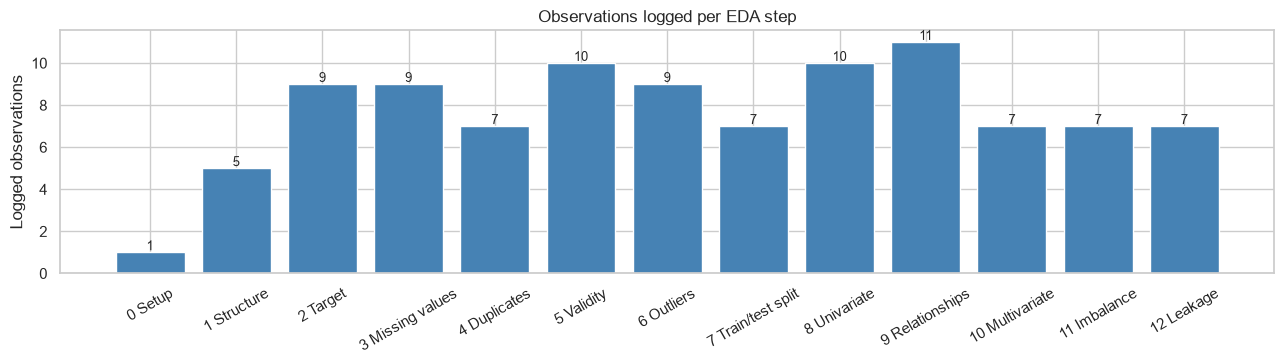

Total observations: 100
Every planned step has entries: PASS
Entries with unexpected step numbers: ['13']


In [26]:
# 13.1 Completeness of the observations log

log = show_obs()
log["step_no"] = log["step"].astype(str).str.split("-").str[0]
PLANNED = {"0": "Setup", "1": "Structure", "2": "Target", "3": "Missing values", "4": "Duplicates",
           "5": "Validity", "6": "Outliers", "7": "Train/test split", "8": "Univariate", "9": "Relationships",
           "10": "Multivariate", "11": "Imbalance", "12": "Leakage"}
counts = pd.Series({f"{k} {v}": int((log["step_no"] == k).sum()) for k, v in PLANNED.items()})

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.bar(counts.index, counts.values, color=["steelblue" if v > 0 else "indianred" for v in counts.values])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.1, str(v), ha="center", fontsize=9)
ax.set(ylabel="Logged observations", title="Observations logged per EDA step")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save_fig("13_observations_per_step")
plt.show()

missing_steps = counts.index[counts == 0].tolist()
extra_labels = sorted(set(log["step_no"]) - set(PLANNED))
print(f"Total observations: {len(log)}")
print("Every planned step has entries:", "PASS" if not missing_steps else f"FAIL - missing {missing_steps}")
if extra_labels:
    print(f"Entries with unexpected step numbers: {extra_labels}")

## 13.2 The observations → decisions table

**What this cell does:** it shows the **complete log** as one table (step, observation, evidence, decision), with the text wrapped so every entry can be read in full, and exports it in two forms:

- `reports/eda_decisions_table.csv`: for spreadsheets;
- `reports/eda_decisions_table.md`: a Markdown table you can paste straight into the report or the README.

**Why this table matters:** it's the **audit trail** of the project. Every preprocessing and modelling choice can be traced back to a row: *what we saw → how we know → what we decided*. In the viva, if someone asks "why did you do X?", the answer is a row in this table.

**How to read the output:** read it top to bottom as the story of the EDA, from raw data quality (Steps 1–6) through the split (7) to the training-set analysis (8–12).

In [27]:
# 13.2 Full observations -> decisions table, exported for the report

table = log[["step", "observation", "evidence", "decision"]].copy()
table["order"] = log["step_no"].astype(int)
table = table.sort_values("order", kind="stable").drop(columns="order").reset_index(drop=True)
table.index = table.index + 1

table.to_csv(REPORT_DIR / "eda_decisions_table.csv", index_label="#")

def to_markdown_table(df):
    # A plain Markdown table (no extra packages needed)
    clean = lambda v: str(v).replace("|", "/").replace("\n", " ")
    lines = ["| # | " + " | ".join(df.columns) + " |", "|---|" + "---|" * len(df.columns)]
    lines += [f"| {i} | " + " | ".join(clean(v) for v in row) + " |" for i, row in zip(df.index, df.to_numpy())]
    return "\n".join(lines)

(REPORT_DIR / "eda_decisions_table.md").write_text(
    "# EDA observations and decisions\n\n" + to_markdown_table(table) + "\n", encoding="utf-8")
print(f"{len(table)} rows saved to reports/eda_decisions_table.csv and reports/eda_decisions_table.md")

with pd.option_context("display.max_colwidth", None):
    display(wrap_style(table))

100 rows saved to reports/eda_decisions_table.csv and reports/eda_decisions_table.md


,step,observation,evidence,decision
1,0-Setup,"Dataset loaded: 384,977 rows x 22 columns",df.shape after pd.read_csv,Use df_raw as untouched reference; all work on df copy
2,1-Structure,"384,977 rows x 22 columns; mix of numeric, binary, categorical, identifier and text fields","df.shape, df.info(), data dictionary",Handle each variable type with its own preprocessing path
3,1-Structure,region has 404 categories of mixed geographic granularity,"df['region'].nunique(), region value_counts",One-hot encoding impractical; consider grouping or target encoding fitted on train only
4,1-Structure,"region names are not unique locations: some names map to up to 3 Craigslist sites (e.g. jacksonville, columbus, rochester exist in multiple states)",region vs region_url mapping check (1.7),"Create unique location key from region_url (or region + state); drop id, url, image_url from features"
5,1-Structure,Binary flags stored as integers; beds/baths are discrete,df.dtypes vs true variable types,Treat flags as categorical 0/1; keep beds/baths numeric
6,1-Structure,"price ranges from 0 to 2,768,307,249",describe() on numeric columns,Investigate target extremes in Step 2
7,2-Target,"price is extremely right-skewed: mean $8,826 vs median $1,036; max $2,768,307,249",2.1 summary statistics and extreme quantiles,"Describe rent with the median, not the mean; report robust metrics (MAE, median absolute error) alongside RMSE"
8,2-Target,"1,307 listings at $0 and 731 at $1 (2,214 below $100 in total); examples are real apartments with no price entered","2.2 threshold counts, 2.3 repeated values, 2.4 example listings","Placeholders, not rents: remove rows with price < $100 before the train/test split"
9,2-Target,"269 listings above $10,000: a mix of genuine luxury homes (large houses in LA, Seattle, SF Bay), sale prices of homes posted as rentals, and nonsense values","2.2 threshold counts, 2.4 example listings, 2.5 full-range histogram","Remove rows with price > $10,000; state in the report that the system is scoped to rents up to $10,000 (too few luxury rows for a model to learn from)"
10,2-Target,Some listings are properties for SALE posted in the rental section (e.g. manufactured homes 'for sale' with a separate lot rent),"2.3 repeated values (e.g. $78,500 x 25), 2.4 example descriptions","In Step 5, search descriptions for sale wording, since cheaper sale listings may sit inside the valid range"


## 13.3 The pipeline specification

**What this cell does:** it writes down, **column by column, how the preprocessing pipeline must treat each input**, for the two families of models, with the EDA evidence for each choice. It saves it to `reports/pipeline_spec.csv`.

**Why two model families?**

- **Ridge, k-NN and the MLP** are **scale-sensitive**: they compare or combine raw numbers, so a feature measured in thousands (square feet) would drown out a 0/1 flag. They need logs for skewed values and **standardisation** (mean 0, spread 1).
- **Random Forest and LightGBM** are **trees**: they only ask "is this value above or below a split point?", so scaling and logs change nothing for them.

**This table is the contract for `src/features.py`:** the next code we write must implement exactly this, inside one scikit-learn `Pipeline`/`ColumnTransformer`, so every learned step is fitted on training folds only (Step 12).

**How to read the output:** one row per column (plus the target and the rows for excluded columns), with the treatment for each model family and the step that justifies it.

In [28]:
# 13.3 Pipeline specification (the contract for src/features.py)

spec = pd.DataFrame([
    ("price (target)", "log1p; predictions back-transformed with expm1 (TransformedTargetRegressor)", "same", "2, 11"),
    ("sqfeet", "log1p, then standardise", "raw", "8.2, 10.4"),
    ("beds, baths", "numeric counts, standardise, no log; read beds 'at the same size'", "raw", "8.3, 10.2"),
    ("lat, long", "fill blanks with the region's median (training folds; state fallback), standardise", "same fill, no scaling", "3, 8.4, 10.3"),
    ("region_url", "cross-fitted target encoding with smoothing; compare state-prior (grouped cross-fitting) vs TargetEncoder", "same", "8.5, 9.7, 10.5, 12.5"),
    ("state", "one-hot (51 columns)", "one-hot (or native categorical)", "9.6, 10.5"),
    ("type, laundry_options, parking_options", "one-hot; blanks -> 'missing'; min_frequency=RARE_MIN_COUNT, handle_unknown='infrequent_if_exist'", "same", "3, 9.4, 11.4"),
    ("6 binary flags", "0/1, standardise", "0/1", "8.7, 9.5"),
    ("student_layout indicator (optional)", "0/1 from beds and baths; keep only if grouped CV improves", "same", "10.7, 11.6"),
    ("excluded: id, url, image_url, region, description", "never features", "never features", "1, 12.1, 12.3"),
    ("group_id", "only for GroupKFold folds", "same", "7, 12.6"),
    ("model selection", "GroupKFold(5) on group_id; beat the location-only baseline", "same", "7, 11.2, 12.6"),
    ("evaluation", "MAE, RMSE, median abs %, R2 (log); per error-analysis group", "same", "11.3, 11.7"),
], columns=["column / item", "Ridge, k-NN, MLP", "Random Forest, LightGBM", "evidence (step)"]).set_index("column / item")
spec.to_csv(REPORT_DIR / "pipeline_spec.csv")
with pd.option_context("display.max_colwidth", None):
    display(wrap_style(spec))
print(f"Saved to {REPORT_DIR / 'pipeline_spec.csv'}")

,"Ridge, k-NN, MLP","Random Forest, LightGBM",evidence (step)
column / item,,,
price (target),log1p; predictions back-transformed with expm1 (TransformedTargetRegressor),same,"2, 11"
sqfeet,"log1p, then standardise",raw,"8.2, 10.4"
"beds, baths","numeric counts, standardise, no log; read beds 'at the same size'",raw,"8.3, 10.2"
"lat, long","fill blanks with the region's median (training folds; state fallback), standardise","same fill, no scaling","3, 8.4, 10.3"
region_url,cross-fitted target encoding with smoothing; compare state-prior (grouped cross-fitting) vs TargetEncoder,same,"8.5, 9.7, 10.5, 12.5"
state,one-hot (51 columns),one-hot (or native categorical),"9.6, 10.5"
"type, laundry_options, parking_options","one-hot; blanks -> 'missing'; min_frequency=RARE_MIN_COUNT, handle_unknown='infrequent_if_exist'",same,"3, 9.4, 11.4"
6 binary flags,"0/1, standardise",0/1,"8.7, 9.5"
student_layout indicator (optional),0/1 from beds and baths; keep only if grouped CV improves,same,"10.7, 11.6"


Saved to C:\Projects\FDM Project\fdm-rental-price\reports\pipeline_spec.csv


## 13.4 Limitations

**What this cell does:** it lists every **known limitation** of the data and the system found during the EDA, with the evidence and what it means for users of the platform, and saves the list to `reports/limitations.csv`.

**Why a limitations list is a strength, not a weakness:** every real dataset has problems. Examiners look for students who **know** where their system can go wrong and say so honestly, with evidence. A report that claims no limitations looks naive; a report that names them precisely and shows how each was handled looks professional.

**How to read the output:** each row answers three questions: *what's the problem, how do we know, and what does it mean for someone using the prediction?* The last column is a good source for the "caveats" text on the platform's result page.

In [29]:
# 13.4 Known limitations

limitations = pd.DataFrame([
    ("Scope: rents $250-$10,000 per month only", "Steps 2, 5.9: placeholders, weekly rates and sale prices outside",
     "The platform should refuse or warn outside this range"),
    ("Sizes are often estimates (heaping)", "Step 8.2: 21.4% multiples of 100 sq ft vs ~1% expected",
     "Caps how precisely size can predict rent"),
    ("smoking_allowed is probably a form default", "Step 1/8.7: 67% 'yes'",
     "Its effect on rent is not trustworthy as a policy effect"),
    ("Per-bedroom pricing in student housing", "Steps 10.7, 11.6: 4-bed/4-bath median $830; per-bed wording 4x more common",
     "Predictions for 4+ bed homes with a bath per bedroom are unreliable, especially in college towns"),
    ("Sale listings with rent-like prices may remain", "Step 5.8: sale wording not usable as a rule",
     "Small residual noise in the target"),
    ("Thin coverage of small regions and mixed markets", "Step 11.5: error 25.1% in regions < 30 listings vs 18.5% in 500+",
     "Less reliable predictions in rural areas and resort regions"),
    ("Few very expensive homes", "Step 11.1: 0.7% of listings above $4,000",
     "Luxury rents are likely to be under-predicted"),
    ("Listings from the same building or agent can share photos", "Step 12.4: shared photos across the split",
     "Test score may be slightly optimistic for known buildings"),
    ("One collection period (snapshot)", "Step 12.2: posting-order check",
     "Rents describe the collection period; retrain before real use"),
    ("Craigslist listings are asking rents", "Data source",
     "Predictions are asking prices, not signed-lease rents"),
], columns=["limitation", "evidence", "what it means for users"]).set_index("limitation")
limitations.to_csv(REPORT_DIR / "limitations.csv")
with pd.option_context("display.max_colwidth", None):
    display(wrap_style(limitations))
print(f"Saved to {REPORT_DIR / 'limitations.csv'}")

,evidence,what it means for users
limitation,,
"Scope: rents $250-$10,000 per month only","Steps 2, 5.9: placeholders, weekly rates and sale prices outside",The platform should refuse or warn outside this range
Sizes are often estimates (heaping),Step 8.2: 21.4% multiples of 100 sq ft vs ~1% expected,Caps how precisely size can predict rent
smoking_allowed is probably a form default,Step 1/8.7: 67% 'yes',Its effect on rent is not trustworthy as a policy effect
Per-bedroom pricing in student housing,"Steps 10.7, 11.6: 4-bed/4-bath median $830; per-bed wording 4x more common","Predictions for 4+ bed homes with a bath per bedroom are unreliable, especially in college towns"
Sale listings with rent-like prices may remain,Step 5.8: sale wording not usable as a rule,Small residual noise in the target
Thin coverage of small regions and mixed markets,Step 11.5: error 25.1% in regions < 30 listings vs 18.5% in 500+,Less reliable predictions in rural areas and resort regions
Few very expensive homes,"Step 11.1: 0.7% of listings above $4,000",Luxury rents are likely to be under-predicted
Listings from the same building or agent can share photos,Step 12.4: shared photos across the split,Test score may be slightly optimistic for known buildings
One collection period (snapshot),Step 12.2: posting-order check,Rents describe the collection period; retrain before real use


Saved to C:\Projects\FDM Project\fdm-rental-price\reports\limitations.csv


## 13.5 Log the summary

**What this cell does:** it adds one closing entry for Step 13, recording that the EDA is complete and where the hand-over documents are, and shows the final count of logged observations per step.

In [30]:
# 13.5 Close the EDA log

clear_obs("13")
log_obs("13-Summary",
        f"EDA complete: {len(table)} logged observations across {int((counts > 0).sum())} of {len(PLANNED)} steps; "
        f"{len(register)} leakage risks, {len(open_risks)} open",
        "13.1-13.4; reports/eda_decisions_table.md, pipeline_spec.csv, leakage_audit.csv, limitations.csv",
        "Proceed to preprocessing (src/features.py) and modelling" if not open_risks and not missing_steps
        else "Resolve open risks / missing steps before modelling")
show_obs(13)

,step,observation,evidence,decision
0,13-Summary,EDA complete: 100 logged observations across 1...,"13.1-13.4; reports/eda_decisions_table.md, pip...",Resolve open risks / missing steps before mode...


---

## Steps 12–13 findings – what our data showed

*This cell is completed after the notebook has been run and reviewed: the interpretation of each section, the decisions, and the viva points, written from the actual outputs above.*

---

## Viva preparation: likely questions on the EDA

Short, evidence-based answers drawn from Steps 1–11 (Step 12 numbers are added after the run).

**1. Why did you log-transform the rent?**
The raw rents are strongly right-skewed (skew 2.70 on the training set); `log1p` brings it down to 0.39. On the log scale, effects are proportional (a feature adds the same % to a $700 and a $3,000 rent), and large errors on expensive homes don't dominate training. Predictions are converted back with `expm1`.

**2. Why remove duplicates before splitting, and why a grouped split?**
49.7% of valid listings were identical to another as far as the model can see (features + price). Without deduplication, 58.9% of test listings had an identical twin in training. After deduplication, 37.1% of listings still had a close relative (repost at another price, or near-identical text); a random split would have put 34.72% of test listings next to one. The grouped split brought that to 0%.

**3. How did you handle missing values?**
Parking (31.5%) and laundry (18.1%) blanks became their own `"missing"` category, because blanks are not random (they depend on state, property type and poster effort) and their rents sit mid-range, unlike any real category. Mode imputation would have been wrong: the mode, "w/d in unit", rents for $1,299 vs $1,010 for blanks. Missing coordinates are filled from the region's median, learned on training data only.

**4. What drives rent?**
Location first: region alone explains 48% of the variation in log rent, state 31%. Then size (sqfeet 14%; within a region, size explains 32% of what's left), amenities (in-unit laundry +19%, attached garage +36%), and building-quality proxies (EV charging +47%, wheelchair access +14%).

**5. Why Ridge rather than plain linear regression?**
The size features overlap (Spearman 0.66–0.80), and the bedroom coefficient flips sign once size is held constant (+9.6% → −11.7%). Ridge's penalty keeps overlapping coefficients stable, and the one-hot and encoded location columns add more overlap.

**6. How do you encode 413 regions?**
Smoothed, cross-fitted target encoding. One-hot would create 413 sparse columns, 29 of them for regions with fewer than 30 listings. Smoothing pulls small regions towards a prior; we showed that the **state** average is twice as accurate a prior as the national average (22.7% vs 44.0% typical error), so we test a state-prior encoder.

**7. Why didn't you merge rare categories?**
Their rents differ too much: 32% spread among rare property types and 65% between "no parking" and "valet parking". Every category with 50+ training listings keeps its own column.

**8. What does "imbalance" mean for a regression problem?**
Thinly covered parts of the target and feature space. Only 0.7% of listings rent above $4,000. A region-median baseline is off by −58% there, can't predict above $4,000 at all, and is weakest in small regions and for per-room student lets. We keep the natural population, model on the log scale, and report errors by price band.

**9. What is your baseline?**
The region median, evaluated with grouped 5-fold cross-validation: MAE $318, median error 18.8%, R² 0.468 on log rent. Every model must clearly beat it.

**10. What was the most surprising finding?**
Per-bedroom pricing: in college towns, 4-bed/4-bath apartments are advertised at the price of one room (median $830, $207 per bedroom). We found it only by combining beds and baths, confirmed it with price per square foot, description wording and location, and handled it as a documented limitation because the cleaning rules were frozen before the split.

---

## What's next: preprocessing and modelling

The EDA is complete. The next stage builds `src/features.py`, the pipeline from 13.3 in scikit-learn (`ColumnTransformer` + `TransformedTargetRegressor`), and the first modelling notebook: the five models (Ridge, k-NN, Random Forest, LightGBM, MLP) compared with **grouped 5-fold cross-validation** against the location-only baseline, on the training set only.